<a href="https://colab.research.google.com/github/Sibitenda/PhDumu/blob/main/big-data/week5_realtime_pipeline_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 Real-Time ML Pipeline
API → Data Quality → Bias → ML → Cloud Storage

This notebook uses real-time data (API) instead of BigQuery.

## Setup

In [14]:
!pip install -q pandas scikit-learn requests pyarrow google-cloud-bigquery

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

## 1. Real-Time Data Acquisition (API)
Using exchange rate API (live data)

In [15]:
url = "https://open.er-api.com/v6/latest/USD"
data = requests.get(url).json()

rates = pd.DataFrame(data['rates'].items(), columns=['currency', 'rate'])
rates.head()

,currency,rate
0,USD,1.000000
1,AED,3.672500
2,AFN,64.586515
3,ALL,81.236834
4,AMD,374.189694


## 2. Data Audit

In [16]:
print("Shape:", rates.shape)
print(rates.dtypes)
print(rates.isnull().sum())
display(rates.describe())

Shape: (166, 2)
currency     object
rate        float64
dtype: object
currency    0
rate        0
dtype: int64


,rate
count,1.660000e+02
mean,8.561377e+03
std,9.029510e+04
min,2.242800e-02
25%,2.902734e+00
50%,2.239346e+01
75%,1.825886e+02
max,1.160586e+06


## 3. Data Cleaning

In [17]:
df_clean = rates.dropna()
df_clean = df_clean[df_clean['rate'] > 0]
df_clean.head()

,currency,rate
0,USD,1.000000
1,AED,3.672500
2,AFN,64.586515
3,ALL,81.236834
4,AMD,374.189694


## 4. Exploratory Data Analysis

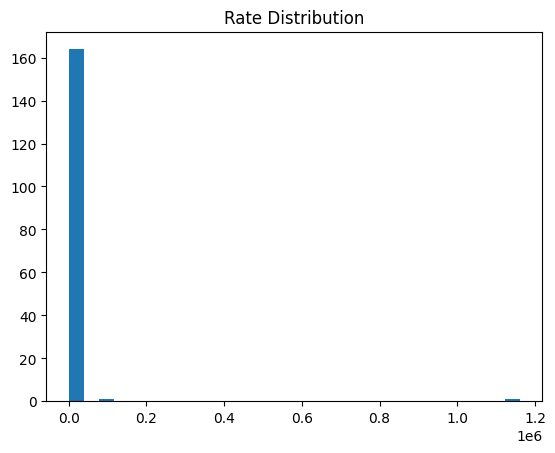

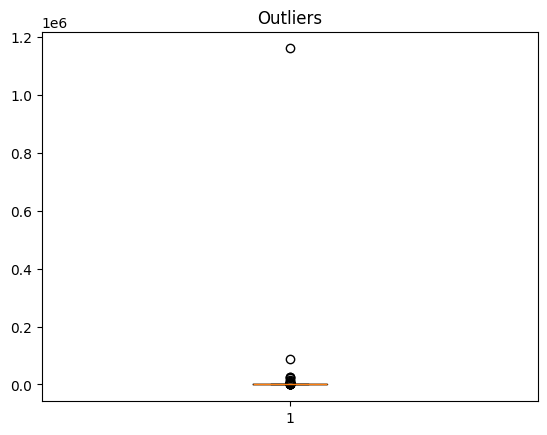

In [18]:
plt.hist(df_clean['rate'], bins=30)
plt.title("Rate Distribution")
plt.show()

plt.boxplot(df_clean['rate'])
plt.title("Outliers")
plt.show()

## 5. Feature Engineering

In [19]:
df_clean['log_rate'] = np.log(df_clean['rate'])
df_clean['label'] = (df_clean['rate'] > df_clean['rate'].median()).astype(int)

X = df_clean[['rate', 'log_rate']]
y = df_clean['label']

## 6. Train/Test Split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

## 7. Model Training

In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

preds = model.predict(X_test)

## 8. Evaluation

In [22]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 1.0


## 9. Bias Check

In [23]:
print("Label Distribution:")
print(y.value_counts(normalize=True))

Label Distribution:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


## 10. Save to BigQuery

In [24]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
# PROJECT_ID = "your-project-id"
PROJECT_ID = "bigdata1-491608"  # put yours
client = bigquery.Client(project=PROJECT_ID)

table_id = f"{PROJECT_ID}.week5.realtime_results"

client.create_dataset(f"{PROJECT_ID}.week5", exists_ok=True)

job = client.load_table_from_dataframe(df_clean, table_id)
job.result()

print("Saved to BigQuery")

Saved to BigQuery
